# Atividade 5 ? Evolu??o do IDHM por UF

An?lise da tabela `Tabela4.csv` e gr?ficos com Matplotlib.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

## Leitura e limpeza dos dados

In [11]:
df = pd.read_csv('Tabela4.csv', sep=';', decimal=',', skiprows=1, encoding='latin1')
df = df.dropna(axis=1, how='all')

anos = [coluna for coluna in df.columns if str(coluna).isdigit()]
id_vars = [coluna for coluna in df.columns if coluna not in anos]
df[anos] = df[anos].apply(pd.to_numeric, errors='coerce')

df.head()

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


## Ranking de 2024 e compara??o com 1991

In [12]:
ranking_2024 = df[['Sigla', 'Estado', '2024']].sort_values('2024', ascending=False)
ranking_2024

,Sigla,Estado,2024
6,DF,Distrito Federal,0.866
25,SP,São Paulo,0.838
23,SC,Santa Catarina,0.833
17,PR,Paraná,0.822
18,RJ,Rio de Janeiro,0.819
22,RS,Rio Grande do Sul,0.818
8,GO,Goiás,0.815
12,MT,Mato Grosso,0.812
10,MG,Minas Gerais,0.809
7,ES,Espírito Santo,0.804


In [13]:
df['Melhoria_1991_2024'] = df['2024'] - df['1991']
maior_melhoria = df.loc[df['Melhoria_1991_2024'].idxmax()]

print(f"Maior melhoria: {maior_melhoria['Estado']} ({maior_melhoria['Sigla']})")
print(f"Varia??o: {maior_melhoria['Melhoria_1991_2024']:.3f}")

pioraram = df.loc[df['2024'] < df['1991'], ['Sigla', 'Estado', '1991', '2024']]
print('Estados que pioraram de 1991 para 2024:')
print('Nenhum estado.' if pioraram.empty else pioraram.to_string(index=False))

Maior melhoria: Tocantins (TO)
Varia??o: 0.428
Estados que pioraram de 1991 para 2024:
Nenhum estado.


## Formato longo (`melt`)

In [14]:
df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name='Ano',
    value_name='IDH'
)
df_longo['Ano'] = df_longo['Ano'].astype(int)
df_longo['IDH'] = pd.to_numeric(df_longo['IDH'], errors='coerce')
df_longo.head()

,Sigla,Código,Estado,Ano,IDH
0,AC,12,Acre,1991,0.402
1,AL,27,Alagoas,1991,0.370
2,AM,13,Amazonas,1991,0.430
3,AP,16,Amapá,1991,0.472
4,BA,29,Bahia,1991,0.386


## Evolu??o do IDH de Minas Gerais

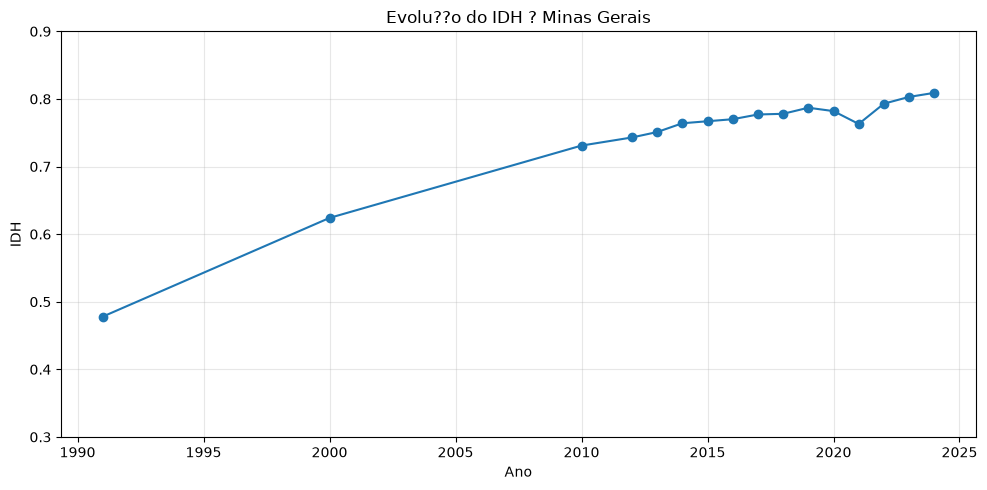

In [15]:
mg = df_longo[df_longo['Sigla'] == 'MG'].sort_values('Ano')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mg['Ano'], mg['IDH'], marker='o', color='tab:blue')
ax.set_title('Evolu??o do IDH ? Minas Gerais')
ax.set_xlabel('Ano')
ax.set_ylabel('IDH')
ax.set_ylim(0.3, 0.9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Evolu??o do IDH de todas as UFs

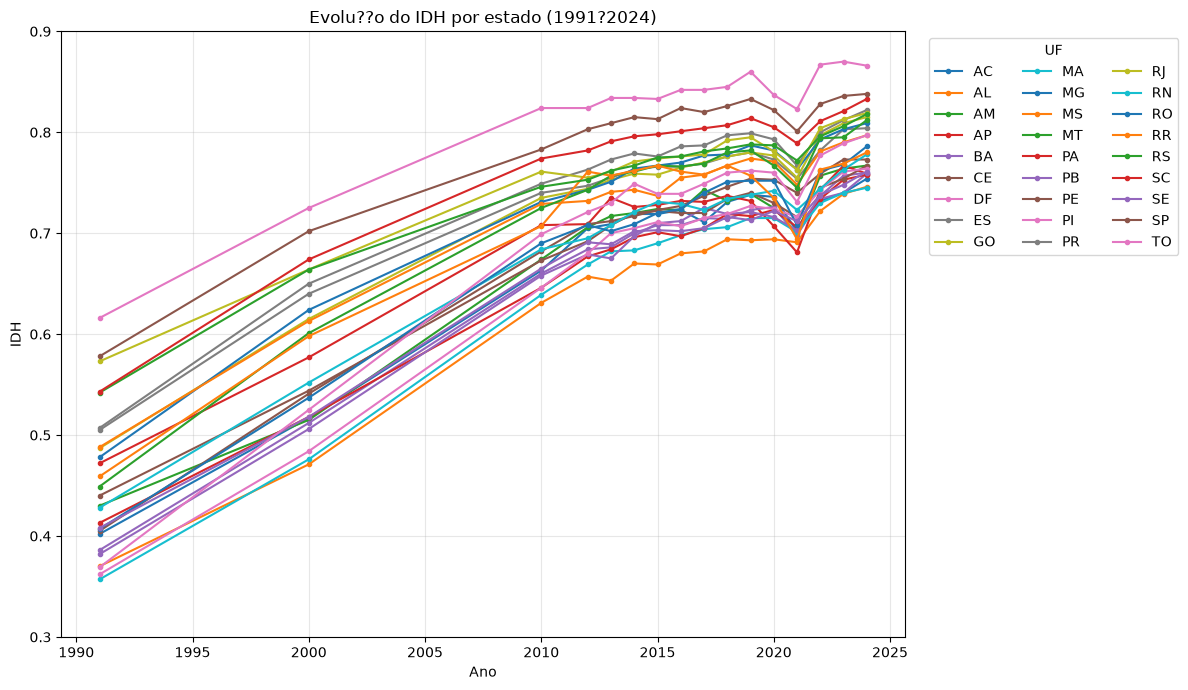

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby('Sigla'):
    grupo = grupo.sort_values('Ano')
    ax.plot(grupo['Ano'], grupo['IDH'], marker='o', markersize=3, linewidth=1.5, label=sigla)

ax.set_title('Evolu??o do IDH por estado (1991?2024)')
ax.set_xlabel('Ano')
ax.set_ylabel('IDH')
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc='upper left', title='UF')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()